In [48]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "rohanbhuin"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
#else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/rohanbhuin/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: April 10, 2026

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Answer:** The objective of this experiment is to evaluate whether different shoe design factors, such as sole material, insole thickness, and fabric breathability, have meaningful effects on perceived comfort of a new running shoe model.

2.  Specify the outcome variable and how it is measured.

**Answer:** The outcome variable is the comfort rating of the running shoe. It is measured on a scale from 1 to 10, where 1 indicates very uncomfortable and 10 indicates very comfortable. This variable is quantitative and continuous.

3.  Specify the independent variables. What lurking variables may be present?

**Answer:** The independent variables in this experiment are:

* **Sole Material (A):** EVA foam vs. Gel-infused foam
* **Insole Thickness (B):** 3 mm vs. 6 mm
* **Fabric Breathability (C):** Woven fabric vs. Mesh fabric

These are all categorical variables with two levels each.

Some possible lurking variables that may be present include:

* Prior preference for shoe types or brands
* Athlete's foot shape
* Athlete's running style or stride pattern
* Athlete's energy level at the time of testing
* Treadmill pace or intensity during the 30-minute run

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

**Answer:** A **full factorial design** is an experimental design in which **all possible combinations of the factor levels** are included in the study. In general, the factors in a full factorial design may have any number of levels.

A **$2^k$ factorial design** is a special case of a full factorial design in which there are **$k$ factors** and **each factor has exactly two levels**. In this experiment, there are 3 factors and each factor has 2 levels, so this is a **full $2^3$ factorial design**, which results in $2^3 = 8$ treatment combinations.

A $2^k$ factorial design may be preferred in this case because each of the shoe design factors naturally has two practical levels to compare. It is also an efficient design since it allows the researchers to study all main effects and interaction effects while keeping the number of treatment combinations manageable.

5.  State the sets of null and alternative hypotheses for this experiment.

**Answer:**
* Main effects:

$$
H_{0A}: \alpha_i = 0 \text{ for all } i
$$

$$
H_{1A}: \alpha_i \ne 0 \text{ for at least one } i
$$

$$
H_{0B}: \beta_j = 0 \text{ for all } j
$$

$$
H_{1B}: \beta_j \ne 0 \text{ for at least one } j
$$

$$
H_{0C}: \gamma_k = 0 \text{ for all } k
$$

$$
H_{1C}: \gamma_k \ne 0 \text{ for at least one } k
$$

* Two-way interactions:

$$
H_{0AB}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j
$$

$$
H_{1AB}: (\alpha\beta)_{ij} \ne 0 \text{ for at least one } i,j
$$

$$
H_{0AC}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k
$$

$$
H_{1AC}: (\alpha\gamma)_{ik} \ne 0 \text{ for at least one } i,k
$$

$$
H_{0BC}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k
$$

$$
H_{1BC}: (\beta\gamma)_{jk} \ne 0 \text{ for at least one } j,k
$$

* Three-way interaction:

$$
H_{0ABC}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k
$$

$$
H_{1ABC}: (\alpha\beta\gamma)_{ijk} \ne 0 \text{ for at least one } i,j,k
$$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer:**

In [49]:
## Question 6 Code ##
## Import Relevant Libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load the Data ##
shoe_data = pd.read_excel("Shoe Comfort Experiment.xlsx")

## Data Integrity Check ##
print(shoe_data.info())

## Set Plot Style ##
sns.set_style("whitegrid")

## Exploratory Data Analysis ##
## Start with Main Effects ##

## Sole Material ##
sole_stats = shoe_data.groupby("sole_material")["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Sole Material")
print(sole_stats)
print()

## Insole Thickness ##
insole_stats = shoe_data.groupby("insole_thickness")["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Insole Thickness")
print(insole_stats)
print()

## Fabric Breathability ##
breath_stats = shoe_data.groupby("breathability")["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Fabric Breathability")
print(breath_stats)
print()

## Two-Way Interaction Summary Statistics ##

## Sole Material x Insole Thickness ##
sole_insole_stats = shoe_data.groupby(["sole_material", "insole_thickness"])["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Sole Material x Insole Thickness")
print(sole_insole_stats)
print()

## Sole Material x Breathability ##
sole_breath_stats = shoe_data.groupby(["sole_material", "breathability"])["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Sole Material x Breathability")
print(sole_breath_stats)
print()

## Insole Thickness x Breathability ##
insole_breath_stats = shoe_data.groupby(["insole_thickness", "breathability"])["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Insole Thickness x Breathability")
print(insole_breath_stats)
print()

## Three-Way Interaction Summary Statistics ##
three_way_stats = shoe_data.groupby(
    ["sole_material", "insole_thickness", "breathability"]
)["comfort"].agg(['mean', 'std'])
print("Summary Statistics for Sole Material x Insole Thickness x Breathability")
print(three_way_stats)
print()

## Mean Standard Deviation Across the 8 Treatment Combinations ##
mean_sd = three_way_stats["std"].mean()
print("Mean standard deviation across treatment combinations:", mean_sd)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   comfort           24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
Summary Statistics for Sole Material
               mean       std
sole_material                
EVA            7.10  1.068559
Gel            9.05  1.541841

Summary Statistics for Insole Thickness
                  mean       std
insole_thickness                
3mm               7.45  1.375434
6mm               8.70  1.687925

Summary Statistics for Fabric Breathability
                   mean       std
breathability                    
Mesh           7.508333  1.273120
Woven          8.641667  1.808796

Summary Statistics for Sole Material x Ins

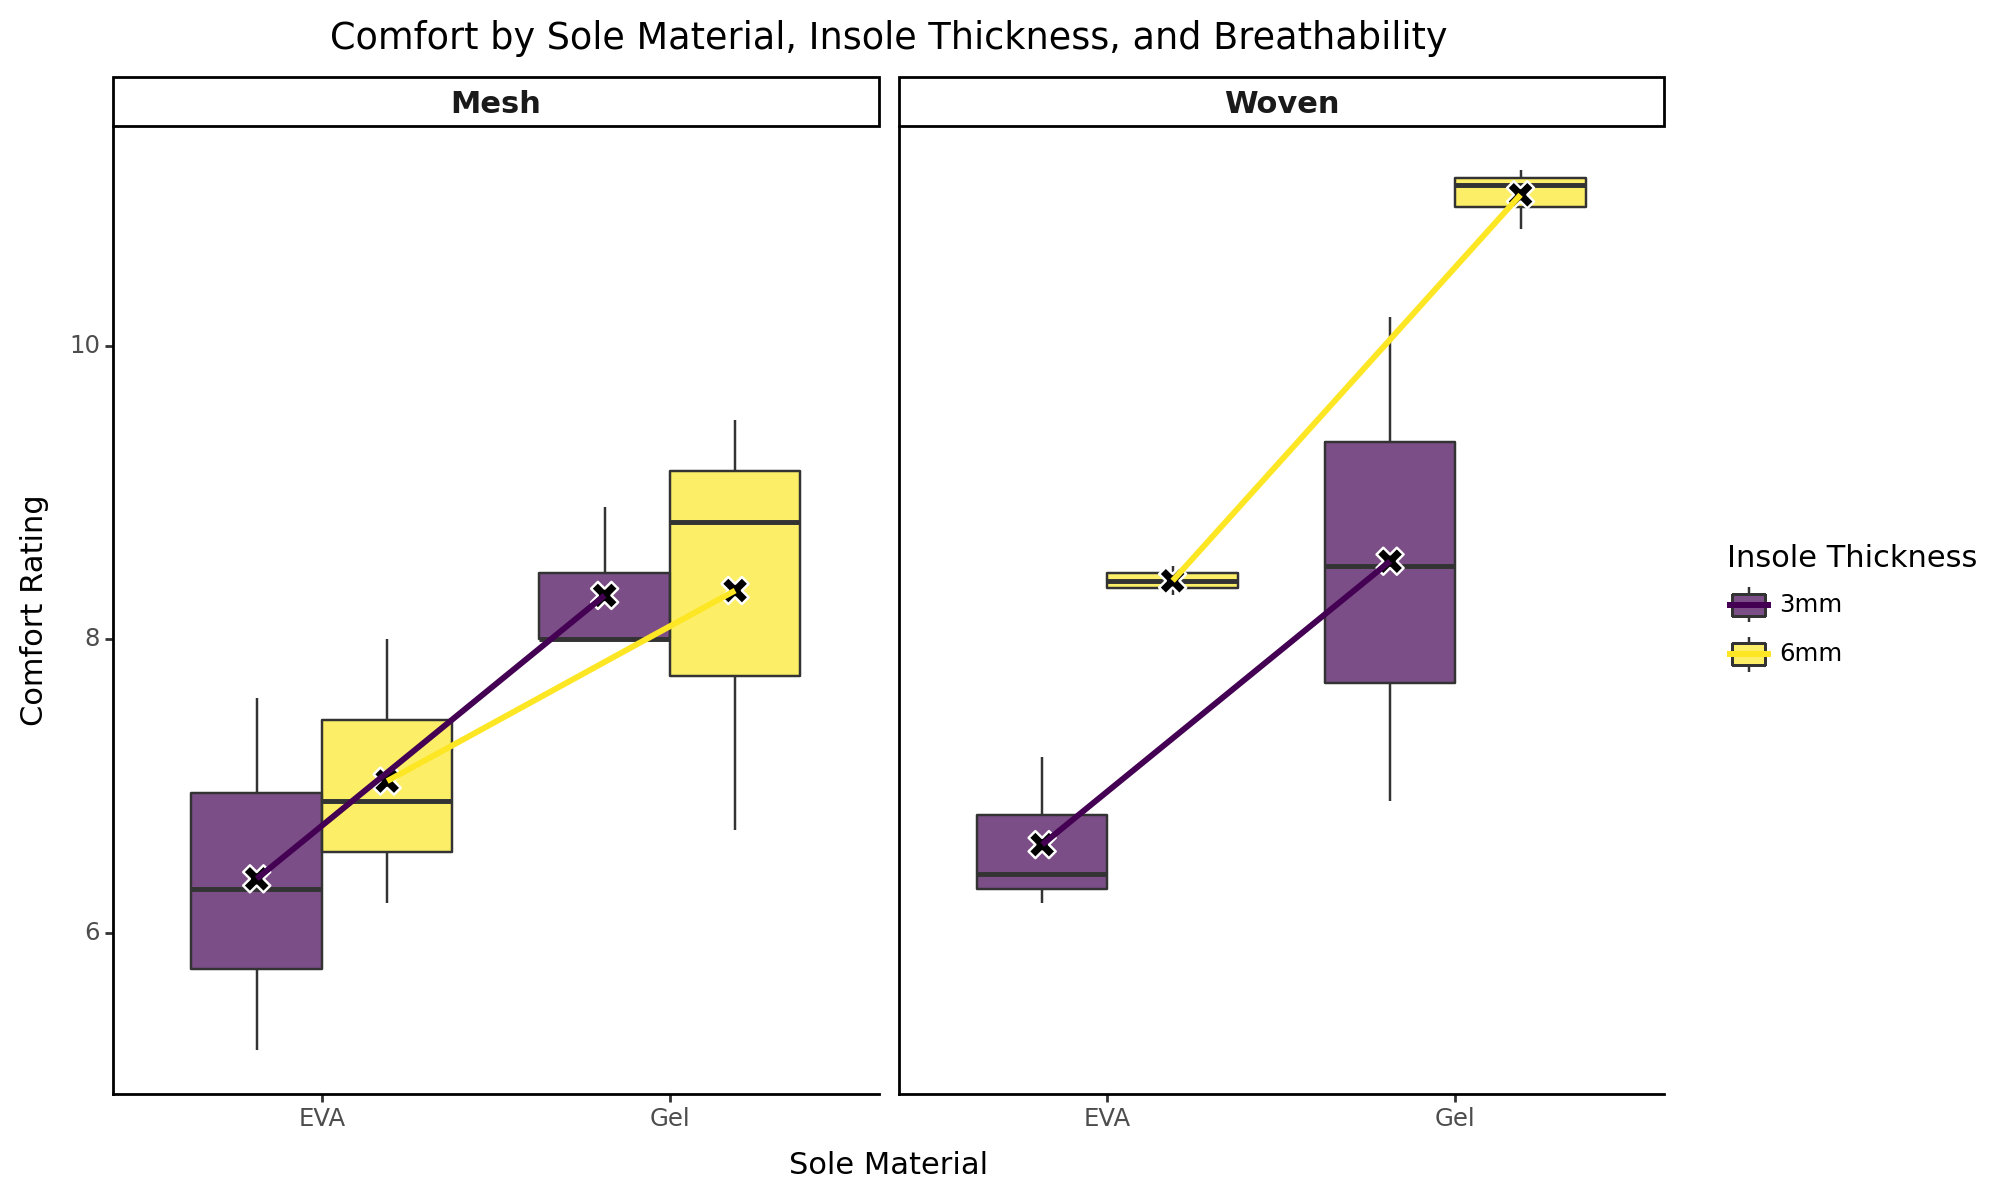

In [50]:
## Visualization ##
## Import all plotnine functions ##
from plotnine import *

## Set factor levels in a clean order ##
shoe_data["sole_material"] = pd.Categorical(
    shoe_data["sole_material"],
    categories=["EVA", "Gel"],
    ordered=True
)

shoe_data["insole_thickness"] = pd.Categorical(
    shoe_data["insole_thickness"],
    categories=["3mm", "6mm"],
    ordered=True
)

shoe_data["breathability"] = pd.Categorical(
    shoe_data["breathability"],
    categories=["Mesh", "Woven"],
    ordered=True
)

## Prepare summarized data ##
shoe_means = (
    shoe_data
    .groupby(["sole_material", "insole_thickness", "breathability"], observed=False)["comfort"]
    .mean()
    .reset_index(name="mean")
)

## Define dodge position for aligning points/lines with the boxplots ##
box_dodge = position_dodge(0.75)

## Build a single faceted plot ##
p = (
    ggplot(shoe_data, aes(x="sole_material", y="comfort")) +

    ## 1. Boxplot layer (base visualization) ##
    geom_boxplot(aes(fill="insole_thickness"), alpha=0.7, position=box_dodge) +

    ## 2. Mean points (using separate summary data) ##
    geom_point(
        data=shoe_means,
        mapping=aes(y="mean", group="insole_thickness"),
        shape="X",
        size=5,
        position=box_dodge,
        color="black"
    ) +

    ## 3. Mean lines ##
    geom_line(
        data=shoe_means,
        mapping=aes(y="mean", group="insole_thickness", color="insole_thickness"),
        size=1.2,
        position=box_dodge
    ) +

    ## 4. Facet by Breathability (two panels side-by-side) ##
    facet_wrap("~breathability", ncol=2) +

    ## 5. Styling and labels ##
    labs(
        title="Comfort by Sole Material, Insole Thickness, and Breathability",
        x="Sole Material",
        y="Comfort Rating",
        fill="Insole Thickness",
        color="Insole Thickness"
    ) +

    theme_classic() +
    theme(
        figure_size=(10, 6),
        plot_title=element_text(ha="center"),
        strip_text=element_text(size=11, weight="bold")
    )
)

## Display ##
p

* Examining the summary statistics for the main effects, we see that:

  * **Gel** had a greater mean comfort rating than **EVA** $(9.05 \text{ vs. } 7.10)$
  * **6mm** insoles had a greater mean comfort rating than **3mm** insoles $(8.70 \text{ vs. } 7.45)$
  * **Woven** fabric had a greater mean comfort rating than **Mesh** fabric $(8.64 \text{ vs. } 7.51)$

* The mean standard deviation across the 8 treatment combinations is about **0.82**. Each of the above main-effect mean differences is greater than about **1 standard deviation**, which provides evidence in favor of the alternative hypothesis for the main effects.

* Looking at the treatment-combination means, the highest mean comfort rating was observed for **Gel + 6mm + Woven** (11.03), while the lowest mean comfort rating was observed for **EVA + 3mm + Mesh** (6.37). This suggests that the choice of factor combination may meaningfully affect comfort.

* Looking at the boxplots and the faceted interaction plot, the data suggest that **Gel**, **6mm**, and **Woven** tend to produce greater comfort ratings overall. In addition, the lines in the interaction plot are not perfectly parallel across the two breathability panels, which suggests that some interaction effects may be present, especially involving **insole thickness** and **breathability**.

* Overall, the exploratory analyses provide stronger support for the **alternative hypotheses** than the null hypotheses, especially for the main effects, while also suggesting that one or more interaction effects may be present.


7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?

**Answer:**

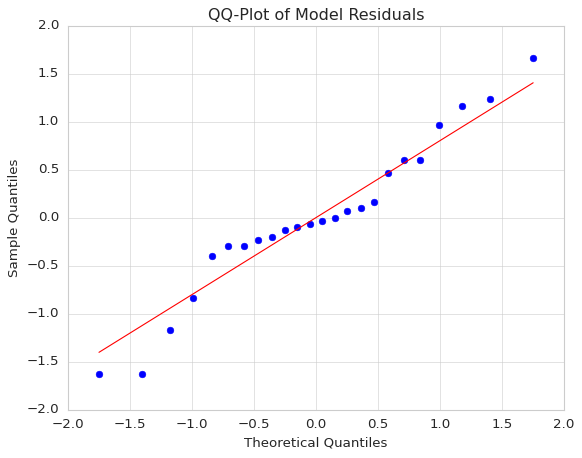

Shapiro-Wilk Test Results:
Statistic: 0.9575037531835807
p-value: 0.39035284823506383
Fail to reject the null hypothesis - Residuals are normally distributed.


In [51]:
## Question 7 Code ##
## Import Statsmodels ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

## Fit Full Factorial Model ##

model = ols('comfort ~ sole_material*insole_thickness*breathability', data=shoe_data).fit()

## Parse out model residuals ##

residuals = model.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")

Looking at the QQ-plot of the model residuals, the points generally follow the diagonal reference line, with only slight deviation in the tails. This provides support for the assumption of normality.

The Shapiro–Wilk test also supports this conclusion. The test produced a statistic of **0.957** with a p-value of **0.390**. Since this p-value is greater than 0.05, we fail to reject the null hypothesis of the Shapiro–Wilk test.

Overall, both the visual method and the formal testing method provide support for the assumption that the residuals are approximately normally distributed.



8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?

**Answer:**

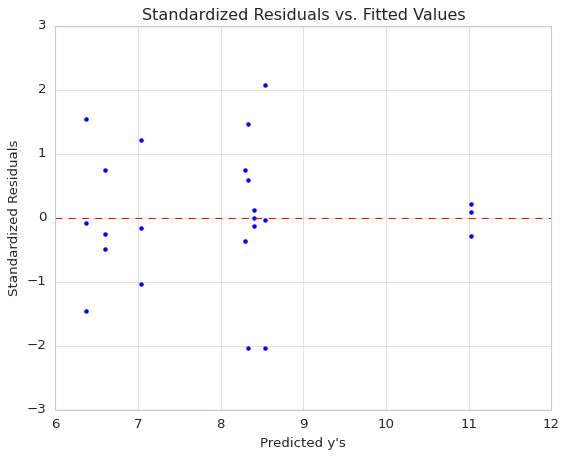

F-statistic: 2.278431684215503
F p-value: 0.0818079385294926
Fail to reject the null hypothesis - Variances are equal.


In [52]:
## Question 8 Code ##
## Import Statsmodels ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Test of Homogeneity of Variance ##

## Scatterplot of Standardized Residuals vs. Fitted Values ##

## Get Standardized Residuals ##

standardized_residuals = model.get_influence().resid_studentized_internal

## Get Fitted Values ##

fitted_values = model.fittedvalues

## Scatterplot ##

## Create the plot ##

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

## Run B-P Test ##

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")

Looking at the scatterplot of standardized residuals versus fitted values, we can see that the residuals appear to be reasonably scattered around zero with no clear systematic pattern. In addition, no points exceed $+3$ or $-3$, which suggests that there is no strong evidence of extreme outliers. The spread of the residuals also appears to be roughly similar across the fitted values, which provides support for the assumption of constant variance.

The Breusch-Pagan test also supports this conclusion. The test produced an F-statistic of **2.278** with an associated p-value of **0.082**. Since this p-value is greater than 0.05, we fail to reject the null hypothesis of constant variance.

Overall, both the visual method and the testing method provide support for the assumption of homogeneity of variance being reasonably met.



9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?

**Answer:**

In [53]:
## Question 9 Code ##
## Generate ANOVA Table ##

anova_table = sm.stats.anova_lm(model, typ=1)

## Add Significance Column ##

anova_table["Significant"] = anova_table["PR(>F)"] < 0.05

## Print Results ##

print(anova_table)

                                                df     sum_sq    mean_sq  \
sole_material                                  1.0  22.815000  22.815000   
insole_thickness                               1.0   9.375000   9.375000   
breathability                                  1.0   7.706667   7.706667   
sole_material:insole_thickness                 1.0   0.001667   0.001667   
sole_material:breathability                    1.0   0.666667   0.666667   
insole_thickness:breathability                 1.0   4.860000   4.860000   
sole_material:insole_thickness:breathability   1.0   0.666667   0.666667   
Residual                                      16.0  15.433333   0.964583   

                                                      F    PR(>F)  Significant  
sole_material                                 23.652700  0.000173         True  
insole_thickness                               9.719222  0.006631         True  
breathability                                  7.989633  0.012155       

### Main effects

* **Sole Material:** $F(1,16)=23.65, p=0.00017$
  The data provide stronger support for the **alternative hypothesis** for sole material.

* **Insole Thickness:** $F(1,16)=9.72, p=0.00653$
  The data provide stronger support for the **alternative hypothesis** for insole thickness.

* **Fabric Breathability:** $F(1,16)=7.99, p=0.01216$
  The data provide stronger support for the **alternative hypothesis** for fabric breathability.

### Two-way interactions

* **Sole Material $\times$ Insole Thickness:** $F(1,16)=0.00, p=0.96736$
  The data provide stronger support for the **null hypothesis** for the sole material by insole thickness interaction.

* **Sole Material $\times$ Fabric Breathability:** $F(1,16)=0.69, p=0.41801$
  The data provide stronger support for the **null hypothesis** for the sole material by fabric breathability interaction.

* **Insole Thickness $\times$ Fabric Breathability:** $F(1,16)=5.04, p=0.03928$
  The data provide stronger support for the **alternative hypothesis** for the insole thickness by fabric breathability interaction.

### Three-way interaction

* **Sole Material $\times$ Insole Thickness $\times$ Fabric Breathability:** $F(1,16)=0.69, p=0.41801$
  The data provide stronger support for the **null hypothesis** for the three-way interaction.

Overall, the data provide stronger support for the alternative hypotheses for all **three main effects** and for the **insole thickness by breathability interaction**, while providing stronger support for the null hypotheses for the other **two-way interactions** and the **three-way interaction**.



10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?

**Answer:**

In [54]:
## Question 10 Code ##
## Load pingouin ##
# !pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(
    dv='comfort',
    between=["sole_material", "insole_thickness", "breathability"],
    data=shoe_data,
    effsize="np2"
).round(4)

print(mod_p[["Source", "np2"]])

                                             Source     np2
0                                     sole_material  0.5965
1                                  insole_thickness  0.3779
2                                     breathability  0.3330
3                  sole_material * insole_thickness  0.0001
4                     sole_material * breathability  0.0414
5                  insole_thickness * breathability  0.2395
6  sole_material * insole_thickness * breathability  0.0414
7                                          Residual     NaN


The partial $\eta^2$ values indicate the proportion of variance in **comfort rating** explained by each effect after accounting for the other effects in the model.

### Main effects

* **Sole Material:** $\eta_p^2 = 0.5965$
  This indicates a **large** effect size.

* **Insole Thickness:** $\eta_p^2 = 0.3779$
  This indicates a **large** effect size.

* **Fabric Breathability:** $\eta_p^2 = 0.3330$
  This indicates a **large** effect size.

### Two-way interactions

* **Sole Material $\times$ Insole Thickness:** $\eta_p^2 = 0.0001$
  This indicates a **negligible** effect size.

* **Sole Material $\times$ Fabric Breathability:** $\eta_p^2 = 0.0414$
  This indicates a **small** effect size.

* **Insole Thickness $\times$ Fabric Breathability:** $\eta_p^2 = 0.2395$
  This indicates a **large** effect size.

### Three-way interaction

* **Sole Material $\times$ Insole Thickness $\times$ Fabric Breathability:** $\eta_p^2 = 0.0414$
  This indicates a **small** effect size.

Overall, the largest effect size was observed for **sole material**, followed by **insole thickness** and **fabric breathability**, suggesting that all three main factors have practically meaningful effects on comfort rating. Among the interaction terms, only the **insole thickness by breathability interaction** appears to have a practically meaningful effect, while the remaining interaction effects appear to be small or negligible.



11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

**Answer:** Based on my analyses, I would recommend the combination of **Gel sole material, 6mm insole thickness, and Woven fabric breathability**. This treatment combination had the highest mean comfort rating $(\bar{y}=11.03)$ among all 8 combinations.

The results showed that **sole material**, **insole thickness**, and **fabric breathability** all had significant main effects on comfort. In addition, there was a significant **insole thickness by breathability interaction**, which suggests that the effect of insole thickness depends on the type of fabric breathability being used.

Overall, these results suggest that comfort is highest when using a **Gel sole**, **6mm insole**, and **Woven fabric**, so this would be my recommended design choice based on the sample data.



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Answer:** The objective of this experiment is to evaluate whether different fitness band design factors, such as GPS accuracy, battery life, and display size, have meaningful effects on perceived user satisfaction.

2.  Specify the outcome variable and how it is measured.

**Answer:** The outcome variable is the satisfaction rating of the fitness band. It is measured on a scale from 1 to 10, where 1 indicates very dissatisfied and 10 indicates very satisfied. This variable is quantitative and continuous.

3.  Specify the independent variables. What lurking variables may be present?

**Answer:** The independent variables in this experiment are:

* **GPS Accuracy (A):** Standard vs. High
* **Battery Life (B):** 6 hours vs. 12 hours
* **Display (C):** Small vs. Large

These are all categorical treatment factors with two levels each.

Some possible lurking variables that may be present include:

* Athlete's preference and prior experience with fitness bands
* Training intensity
* Ease of syncing with other devices
* Charging habits during the study period
* Weather or running conditions

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

**Answer:** A full $2^k$ factorial design is an experimental design in which all possible combinations of the factor levels are included in the study. With 3 factors at 2 levels each, a full $2^3$ design would require $2^3 = 8$ treatment combinations.

A $2^{3-1}$ fractional factorial design is a one-half fraction of the full $2^3$ design, so it requires only $2^{3-1} = 4$ treatment combinations.

The $2^{3-1}$ fractional factorial design may be preferred in this case because it reduces the number of runs, making the experiment more practical in terms of time, cost, and resources, while still allowing the company to study the primary factor effects.

5.  State the sets of null and alternative hypotheses for this experiment.

**Answer:**
For GPS Accuracy $(A)$:

$$
H_{0A}: \mu_{A-} = \mu_{A+}
$$

$$
H_{1A}: \mu_{A-} \ne \mu_{A+}
$$

For Battery Life $(B)$:

$$
H_{0B}: \mu_{B-} = \mu_{B+}
$$

$$
H_{1B}: \mu_{B-} \ne \mu_{B+}
$$

For Display $(C)$:

$$
H_{0C}: \mu_{C-} = \mu_{C+}
$$

$$
H_{1C}: \mu_{C-} \ne \mu_{C+}
$$

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

**Answer:** Assuming the defining relation is

$$
I = ABC
$$

the aliasing structure is:

$$
A = BC
$$

$$
B = AC
$$

$$
C = AB
$$

This means that each main effect is aliased with a two-way interaction. In particular, the main effect of GPS Accuracy is aliased with the Battery Life $\times$ Display interaction, the main effect of Battery Life is aliased with the GPS Accuracy $\times$ Display interaction, and the main effect of Display is aliased with the GPS Accuracy $\times$ Battery Life interaction. As a result, the main effects cannot be interpreted independently of these corresponding two-way interactions.

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Run_ID        12 non-null     int64  
 1   Replicate     12 non-null     int64  
 2   GPS_Accuracy  12 non-null     object 
 3   Battery_Life  12 non-null     object 
 4   Display       12 non-null     object 
 5   Satisfaction  12 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 708.0+ bytes
None

  GPS_Accuracy      mean       std
0         High  7.140000  2.346691
1     Standard  4.606667  1.284098

  Battery_Life      mean       std
0     12 Hours  6.368333  3.189303
1      6 Hours  5.378333  0.496806

  Display      mean       std
0   Large  7.505000  1.957445
1   Small  4.241667  0.886192



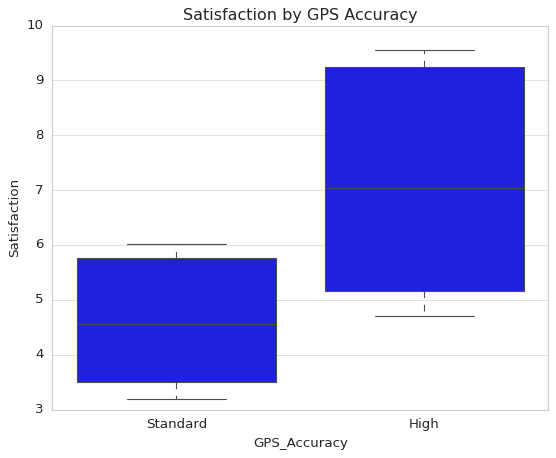

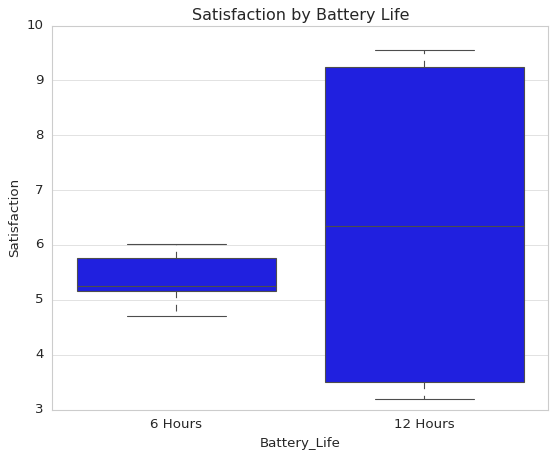

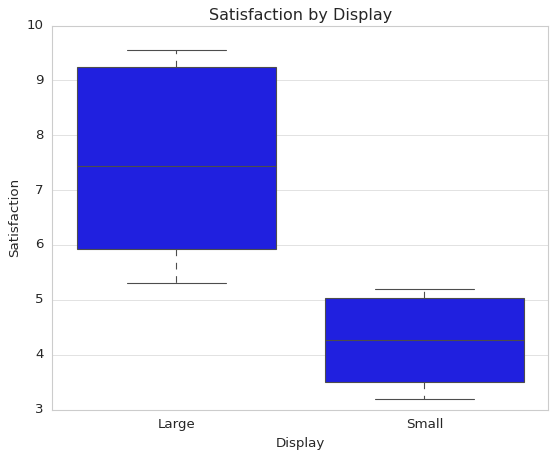

In [55]:
## Question 7 Code ##
## Calculate Summary Statistics for the Main Effects ##

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Load the Data ##
fitness_data = pd.read_excel("Fitness Band Experiment.xlsx")

## Data Integrity Check ##
print(fitness_data.info())
print()

## Set Plot Style ##
sns.set_style("whitegrid")

## GPS Accuracy Effect ##

gps_effect = fitness_data.groupby('GPS_Accuracy')['Satisfaction'].agg(['mean', 'std']).reset_index()

print(gps_effect)
print()

## Battery Life Effect ##

battery_effect = fitness_data.groupby('Battery_Life')['Satisfaction'].agg(['mean', 'std']).reset_index()

print(battery_effect)
print()

## Display Effect ##

display_effect = fitness_data.groupby('Display')['Satisfaction'].agg(['mean', 'std']).reset_index()

print(display_effect)
print()

## Plot Boxplots for Each Factor using seaborn ##

## GPS Accuracy Boxplot ##

sns.boxplot(x='GPS_Accuracy', y='Satisfaction', data=fitness_data)
plt.title('Satisfaction by GPS Accuracy')
plt.show()

## Battery Life Boxplot ##

sns.boxplot(x='Battery_Life', y='Satisfaction', data=fitness_data)
plt.title('Satisfaction by Battery Life')
plt.show()

## Display Boxplot ##

sns.boxplot(x='Display', y='Satisfaction', data=fitness_data)
plt.title('Satisfaction by Display')
plt.show()

* Examining the summary statistics for the main effects, we see that:

  * **High** GPS accuracy had a greater mean satisfaction rating than **Standard** GPS accuracy ($7.14$ vs. $4.61$)
  * **12 Hours** battery life had a greater mean satisfaction rating than **6 Hours** battery life ($6.37$ vs. $5.38$)
  * **Large** display had a greater mean satisfaction rating than **Small** display ($7.51$ vs. $4.24$)

* Looking at the boxplots, the clearest differences appear for **GPS Accuracy** and **Display**, where the higher-performing levels tend to have noticeably greater satisfaction ratings. The difference for **Battery Life** appears smaller and less clear due to greater variability in the 12-hour group.

* Overall, the exploratory analyses provide stronger support for the **alternative hypotheses** for **GPS Accuracy** and **Display**, while the evidence for **Battery Life** appears weaker from the exploratory analysis alone.



8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?

**Answer:**

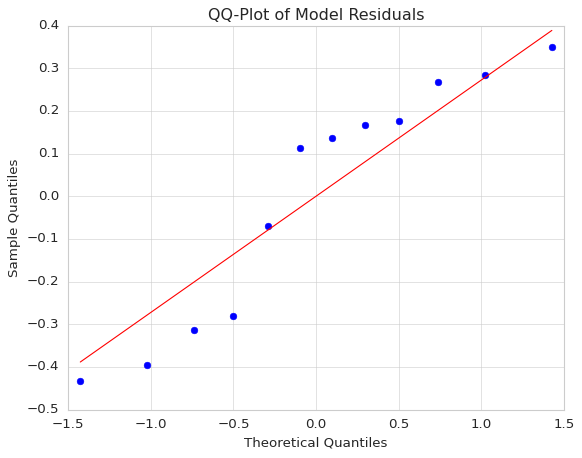

Shapiro-Wilk Test Results:
Statistic: 0.8812973148236574
p-value: 0.09106712364387089
Fail to reject the null hypothesis - Residuals are normally distributed.


In [56]:
## Question 8 Code ##
## Import Statsmodels ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

## Fit Main Effects ANOVA Model ##

model = ols('Satisfaction ~ GPS_Accuracy + Battery_Life + Display', data=fitness_data).fit()

## Parse out model residuals ##

residuals = model.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")

Looking at the QQ-plot of the model residuals, the points generally follow the diagonal reference line, with only slight deviation in the lower tail. This provides reasonable support for the assumption of normality.

The Shapiro-Wilk test also supports this conclusion. The test produced a statistic of **0.881** with a p-value of **0.0911**. Since this p-value is greater than 0.05, we fail to reject the null hypothesis of the Shapiro-Wilk test.

Overall, both the visual method and the formal testing method provide support for the assumption that the residuals are approximately normally distributed.


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?

**Answer:**

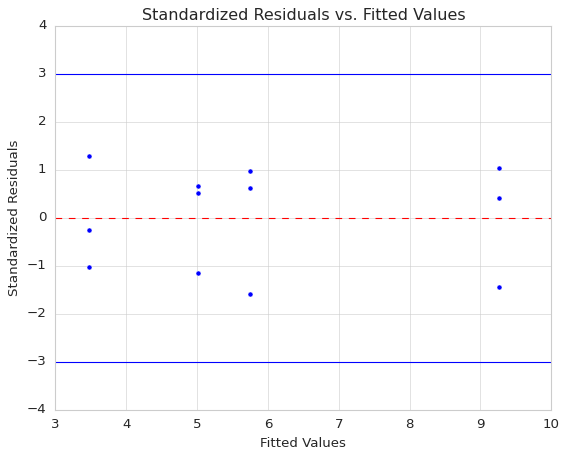

F-statistic: 0.2732704988386917
F p-value: 0.8431259020641402
Fail to reject the null hypothesis - Variances are equal.


In [57]:
## Question 9 Code ##
## Import Statsmodels ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Test of Homogeneity of Variance ##

## Scatterplot of Standardized Residuals vs. Fitted Values ##

## Get Standardized Residuals ##

standardized_residuals = model.get_influence().resid_studentized_internal

## Get Fitted Values ##

fitted_values = model.fittedvalues

## Scatterplot ##

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")

Looking at the scatterplot of standardized residuals versus fitted values, we can see that the residuals appear to be reasonably scattered around zero with no clear systematic pattern. In addition, no points exceed $+3$ or $-3$, which suggests that there is no strong evidence of extreme outliers. The spread of the residuals also appears to be roughly similar across the fitted values, which provides support for the assumption of constant variance.

The Breusch-Pagan test also supports this conclusion. The test produced an $F$-statistic of **0.273** with an associated p-value of **0.843**. Since this p-value is greater than 0.05, we fail to reject the null hypothesis of constant variance.

Overall, both the visual method and the testing method provide support for the assumption of homogeneity of variance being reasonably met.


10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

**Answer:**

In [58]:
## Question 10 Code ##
## Generate ANOVA Table ##

anova_table = sm.stats.anova_lm(model, typ=1)

## Add Significance Column ##

anova_table["Significant"] = anova_table["PR(>F)"] < 0.05

## Print Results ##

print(anova_table)

               df     sum_sq    mean_sq           F        PR(>F)  Significant
GPS_Accuracy  1.0  19.253333  19.253333  172.869435  1.065588e-06         True
Battery_Life  1.0   2.940300   2.940300   26.400000  8.872097e-04         True
Display       1.0  31.948033  31.948033  286.851029  1.498222e-07         True
Residual      8.0   0.891000   0.111375         NaN           NaN        False


* **GPS Accuracy:** $F(1,8)=172.87, p<0.001$
  The data provide stronger support for the **alternative hypothesis** for GPS Accuracy.

* **Battery Life:** $F(1,8)=26.40, p<0.001$
  The data provide stronger support for the **alternative hypothesis** for Battery Life.

* **Display:** $F(1,8)=286.85, p<0.001$
  The data provide stronger support for the **alternative hypothesis** for Display.

Overall, the data provide stronger support for the **alternative hypotheses** for all three main effects. This suggests that **GPS Accuracy**, **Battery Life**, and **Display** each have a statistically significant effect on satisfaction.


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

**Answer:**

In [59]:
## Question 11 Code ##
## Group the Data by the Effect column and pivot from long to wide ##

fitness_data["Effect"] = np.repeat(["c", "a", "b", "abc"], repeats=3)

df = (fitness_data.groupby("Effect", as_index=False)["Satisfaction"].mean())

## Now we want to pivot the DataFrame from long to wide format
## so that each effect is a separate column ##

df = df.pivot_table(index=None, columns="Effect", values="Satisfaction").reset_index(drop=True)

## Extract factor columns for easier use ##

a   = df["a"]
b   = df["b"]
c   = df["c"]
abc = df["abc"]

## Compute factor estimates ##

df2 = pd.DataFrame({
    "A": 0.5 * (a - b - c + abc),
    "B": 0.5 * (-a + b - c + abc),
    "C": 0.5 * (-a - b + c + abc)
})

print(df)
print(df2)

Effect         a       abc     b         c
0       5.013333  9.266667  3.47  5.743333
          A     B         C
0  2.533333  0.99  3.263333


The estimated main effects are:

* **GPS Accuracy $(A)$:** $2.53$
* **Battery Life $(B)$:** $0.99$
* **Display $(C)$:** $3.26$

These results indicate that all three estimated main effects are positive. This suggests that moving from **Standard** to **High** GPS accuracy, from **6 hours** to **12 hours** of battery life, and from **Small** to **Large** display is associated with an increase in mean satisfaction.

Among the three factors, **Display $(C)$** has the largest estimated main effect, followed by **GPS Accuracy $(A)$**, while **Battery Life $(B)$** has the smallest estimated main effect. Thus, based on these effect estimates, **display size appears to have the strongest impact on user satisfaction**.

However, because this is a $2^{3-1}$ fractional factorial design with defining relation $I=ABC$, these main effects are aliased with two-way interactions.


12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

**Answer:**

In [60]:
## Load pingouin ##
# !pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(
    dv='Satisfaction',
    between=["GPS_Accuracy", "Battery_Life", "Display"],
    data=fitness_data,
    effsize="np2",
    detailed=True
).round(4)

## Print only the main effects ##
print(mod_p.loc[mod_p["Source"].isin(["GPS_Accuracy", "Battery_Life", "Display"]), ["Source", "np2"]])

         Source     np2
0  GPS_Accuracy  0.9558
1  Battery_Life  0.7674
2       Display  0.9729


The partial $\eta^2$ values indicate the proportion of variance in **Satisfaction** explained by each main effect after accounting for the other factors in the model.

* **GPS Accuracy:** $\eta_p^2 = 0.9558$
* **Battery Life:** $\eta_p^2 = 0.7674$
* **Display:** $\eta_p^2 = 0.9729$

These results suggest that all three main effects have **large effect sizes**. Among the three factors, **Display** has the largest effect size, followed by **GPS Accuracy**, while **Battery Life** has the smallest effect size. Overall, this suggests that all three factors appear to have practically meaningful effects on user satisfaction, with **Display** appearing to have the strongest effect.


13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

**Answer:** Based on my analyses, I would recommend the combination of **High GPS Accuracy, 12-hour Battery Life, and Large Display**. Since all three estimated main effects were positive, the results suggest that moving to the higher level of each factor is associated with greater mean satisfaction.

Among the three factors, **Display** appeared to have the strongest effect on satisfaction, followed by **GPS Accuracy**, while **Battery Life** had the smallest effect. Overall, these results suggest that satisfaction is highest when using a **High GPS Accuracy**, **12-hour Battery Life**, and **Large Display** configuration, so this would be my recommended design choice based on the sample data.

Because this is a $2^{3-1}$ fractional factorial design, this recommendation should still be interpreted with some caution due to aliasing.
